# Practical exercises

 - This notebook provides practical examples demonstrating the use of machine learning for image processing.

 - The objectives are:
    1. Develop familiarity with data loading and dataset splitting.
    2. Gain exposure to [`PyTorch`](https://docs.pytorch.org/docs/stable/index.html), now the industry standard for developing deep neural networks in Python.
    3. Use [`MONAI`](https://github.com/Project-MONAI/MONAI) for medical image preprocessing and augmentation within the PyTorch ecosystem, including:
        - Image classification
        - Image segmentation
        - Image generation
    4. Use [`scikit-learn`](https://scikit-learn.org/) to provide core machine-learning utilities in Python, including data splitting and model evaluation.
    5. Develop an understanding of factors that influence model performance, including input image quality and generalizability.

 - These exercises do not necessarily represent the state of the art, as training deep-learning models typically requires substantial computational resources and time.

 - However, by the end of this notebook, we hope these exercises will clarify the underlying technology that underpins many state-of-the-art AI techniques.

 - Do not be concerned if you are not a Python expert. We have tried to ensure that all code is well-documented to help guide you through it.

 - You can run the cells as they are to view the output. However, it is worthwhile spending the time to understand the code so that it becomes clearer how AI models are trained in practise.

 - Please do talk to colleagues and the supervisors to help guide you through it where needed. We are here to help.

 - You can run this notebook within Collab using the following link [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mdblackledge/theoryofimaging2/blob/main/notes.ipynb)

     https://colab.research.google.com/github/mdblackledge/theoryofimaging2/blob/main/notes.ipynb

__Note__: It is worth running this notebook as a GPU instance. It will make training much faster.

Hit `Runtime` → `Change runtime type` → `T4 GPU`

 - First we ensure that relevant libraries are installed.
 - In general, Colab comes with most libraries preinstalled, other than `MONAI`.
 - Other important libraries we will use include:
    - `scikit-learn`: General machine learning library.
    - `pytorch`: Deep learning library
    - `matplotlib`: Plotting utilities.
    - `numpy`: Numerical operations.
    - `tqdm`: For plottng progress bars.
    - `kagglehub`: To download free datasets from [kaggle](https://www.kaggle.com/)
    - `google`: For saving and downloading trained models.
 - If running from a local machine, it is worth using [`conda`](https://docs.conda.io/projects/conda/en/latest/user-guide/getting-started.html) for environment management and running the following command:
 ```
 pip install scikit-learn torch matplotlib numpy tqdm kagglehub monai google
 ```

In [2]:
# @title
!pip install -q monai  # Not installed by default on Colab

# __1. The dataset__


## Raw data download
 - In these exercises, we will make use of a free dataset that is available on [_kaggle_](https://www.kaggle.com/) comprising of images of Lego bricks.
 - The next cell will download the dataset and provide visual examples for each of the 16 block groups.
 - Images are downloaded into a folder named `clean_data_path`

100%|██████████| 1.00G/1.00G [00:11<00:00, 93.0MB/s]

Extracting files...


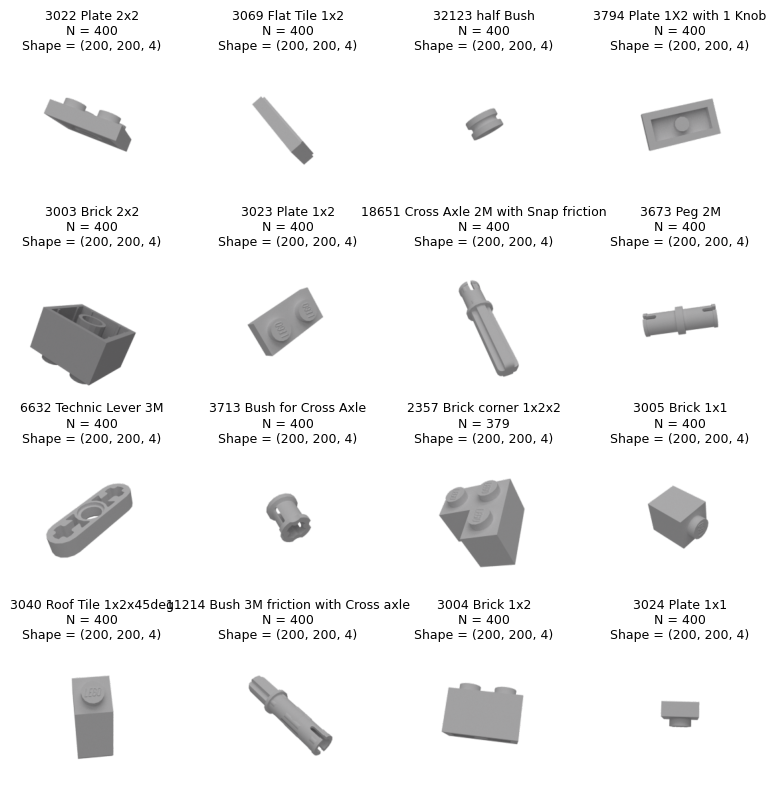



Available block groups
3022 Plate 2x2
3069 Flat Tile 1x2
32123 half Bush
3794 Plate 1X2 with 1 Knob
3003 Brick 2x2
3023 Plate 1x2
18651 Cross Axle 2M with Snap friction
3673 Peg 2M
6632 Technic Lever 3M
3713 Bush for Cross Axle
2357 Brick corner 1x2x2
3005 Brick 1x1
3040 Roof Tile 1x2x45deg
11214 Bush 3M friction with Cross axle
3004 Brick 1x2
3024 Plate 1x1


In [3]:
# @title
import os

import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import skimage

# 1. Download latest version
# ==========================
clean_data_path = kagglehub.dataset_download("joosthazelzet/lego-brick-images")\
                    + "/LEGO brick images v1"

# 2. Plot some examples
# =====================
# Random seed
np.random.seed(2026)

# Obtain a list of the different block types
block_groups = os.listdir(clean_data_path)

f, ax = plt.subplots(4, 4, figsize = (8, 8))
ax = ax.ravel()
for i in range(16):

    # Randomly select a block for each group
    block_group_dir = clean_data_path + "/" + block_groups[i]
    block_file = block_group_dir + "/" + np.random.choice(os.listdir(block_group_dir))

    # Display
    arr = skimage.io.imread(block_file)
    ax[i].imshow(arr)
    ax[i].set_title(block_groups[i] + "\n"\
                    + f"N = {len(os.listdir(block_group_dir))}" + "\n"\
                    + f"Shape = {arr.shape}", fontsize = 9.)
    ax[i].axis("off")

plt.tight_layout()
plt.show()

# 3. Print available block group names
# ====================================
print("\n")
print("Available block groups")
print("======================")
for block_group in block_groups:
    print(block_group)

## Training data
 - As we saw in the lectures, medical images are less than when perfect compared with these examples.
 - They are affected by noise, blurring (_partial volume effects_), and artifacts.
 - We will create a function to artificially degrade these images, whilst also turning them into more _medical-like_ images (single channel with background being zero).  
 - There are two key parameters that may be changed to synthesize these data:
    - `SNR`: The signal-to-noise ratio of the generated images.
    - `SHAPE`: The output chape of the generated images.
 - These may be changed during experiments to interrogate the impact of these parameters on model training.

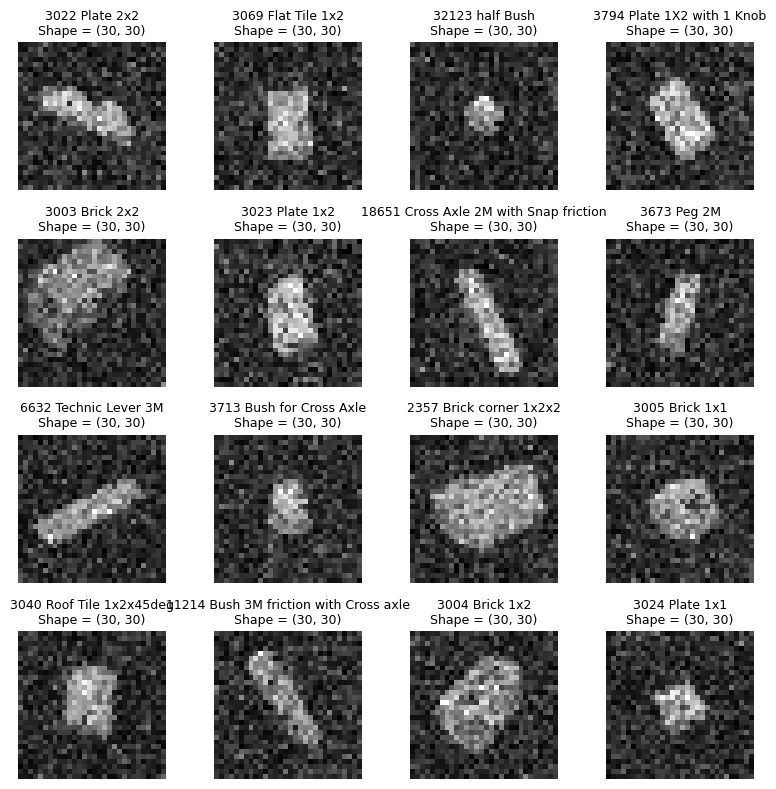

In [4]:
# @title
from skimage.transform import resize

# 1. Define global parameters for the experiments
# ===============================================
SNR = 7.0
SHAPE = (30, 30)

# 2. Define a function for degrading input iamge quality
# ======================================================
def degrade_lego_image(arr, snr = 30.0, shape = (50, 50)):
    """ Degrade the quality of an image of a Lego brick.

    Parameters
    ----------
    arr : numpy.ndarray
        The input image.

    snr : float, optional
        The signal-to-noise ratio.

    shape : (int, int), optional
        The output array shape.

    Returns
    -------
    numpy.ndarray
        The degraded image.
    """
    arr_bw = arr[..., 0].astype("float32")  # Just the first channel
    arr_bw = resize(
        arr_bw,
        shape,
        order=1,               # 1 = bilinear
        mode='reflect',
        anti_aliasing=True,
        preserve_range=True    # keeps original value range
    )

    # We use Rician noise to ensure non-negative values (as in medical imaging)
    sigma = 255.0 / snr
    arr_noisy = np.clip(np.sqrt((arr_bw + np.random.randn(*arr_bw.shape) * sigma) ** 2 +\
                                (np.random.randn(*arr_bw.shape) * sigma) ** 2), 0, 255)
    return arr_noisy.astype("uint8")


# 3. View some random examples in matplotlib
# ==========================================

# Random seed
np.random.seed(2026)

f, ax = plt.subplots(4, 4, figsize = (8, 8))
ax = ax.ravel()
for i in range(16):

    # Randomly select a block type and image
    block_group_dir = clean_data_path + "/" + os.listdir(clean_data_path)[i]
    block_file = block_group_dir + "/" + np.random.choice(os.listdir(block_group_dir))

    # Degrade the image.
    arr = skimage.io.imread(block_file)
    arr_noisy = degrade_lego_image(arr, snr=SNR, shape=SHAPE)

    # Display
    ax[i].imshow(arr_noisy, cmap = "gray")
    ax[i].set_title(block_file.split("/")[-2] + "\n"\
                    + f"Shape = {arr_noisy.shape}", fontsize = 9.)
    ax[i].axis("off")

plt.tight_layout()
plt.show()

 - We will store a seperate set of degraded images in the location:
    
    `input_images_dir = "/content/input_images"`
    
 - This emulates the noisy data you might experience in real life.
 - __Important__: If you change either the `SNR` or `SHAPE` of your data, you will need to re-run this cell.

In [5]:
# @title
from tqdm import tqdm

# 1. Define the location for storage
# ==================================
input_images_dir = "/content/input_images"

# If this is True, then new data will always be saved
# Set to True if you are mdifying the SNR or SHAPE.
force = True

# 2. Save to disk
# ===============
if not os.path.exists(input_images_dir) or force:
    for block_group_dir in tqdm(os.listdir(clean_data_path), desc = "Resampling images"):
        block_group_path = clean_data_path + "/" + block_group_dir
        for block_file in os.listdir(block_group_path):
            block_path = block_group_path + "/" + block_file
            arr = skimage.io.imread(block_path)
            arr_noisy = degrade_lego_image(arr, snr=SNR, shape=SHAPE)
            os.makedirs(input_images_dir + "/" + block_group_dir, exist_ok=True)
            skimage.io.imsave(input_images_dir + "/" + block_group_dir + "/" + block_file, arr_noisy)

Resampling images: 100%|██████████| 16/16 [00:22<00:00,  1.39s/it]


# __2. Binary classifier__
 - In the first problem, we will develop a binary classifier for distinguishing between two block types (labels).
 - We're going to build on a classic neural network architecture __LeNet__.
 - This technology revolusionized the field of AI and has been instrumental in bringing AI to the forefront of daily life.
 - Traditionally, this architecture was developed for 10-class classification tasks (identification of hand-drawn numerical digits).

 <img src="https://raw.githubusercontent.com/mdblackledge/theoryofimaging2/main/workshop/figures/lenet.png?cache_bust=20260216" width=80%>

## Data splitting

 - First, we load the images from two block types, each representing a different class.
 - We retain 50% of the images for later testing of the algorithm.
 - We further split the remaining training data into 50/50 for training and validation.

In [6]:
# @title
import random
from sklearn.model_selection import train_test_split

# 1. Define which blocks we want to classify
# ==========================================
label_0 = "3024 Plate 1x1"
label_1 = "32123 half Bush"

# 2. Load datasets as dictionary lists (usefule format for MONAI
# ==============================================================
label_0_files = [
    {"image": os.path.join(input_images_dir, label_0, fname), "label": 0}
    for fname in os.listdir(os.path.join(input_images_dir, label_0))
    if fname.endswith(".png")
]
label_1_files = [
    {"image": os.path.join(input_images_dir, label_1, fname), "label": 1}
    for fname in os.listdir(os.path.join(input_images_dir, label_1))
    if fname.endswith(".png")
]

# Concatenate into a single list
files = label_0_files + label_1_files

# 3. Split into train/validation/test
# ===================================

# Split into train/test (50/50)
test_fraction = 0.5

files_train, files_test = train_test_split(
    files,
    test_size=test_fraction,
    stratify=[f["label"] for f in files],
    random_state=2026,
)

# Further split into train/validation (50/50)
val_fraction = 0.5
files_train, files_val = train_test_split(
    files_train,
    test_size=val_fraction,
    stratify=[f["label"] for f in files_train],
    random_state=2026,
)

## Data preprocessing and augmentation
 - __Data preprocessing__ ensures that data are standardized before being used for model training or inference.
 - These transforms are deterministic and applied to both training data and during algorithm inference.
 - This includes:
    - Shape standardization: Ensuring that all input images have identical spatial dimensions before being passed to the model.
    - Intensity normalization: Neural networks typically perform better when inputs are normalized, often with values scaled to a consistent range that may include negative values.  
    - Data type standardization: Ensuring inputs are converted to a consistent numerical type (e.g., `float32`) before being passed to the network.
    - Channel formatting: Making sure data follow a consistent shape convention (e.g., channel-first format (`C, H, W`) for `torch`).
    - Label formatting: Converting labels into the required form (e.g., integer class indices, one-hot encoding, or tensor format).
    - Rescaling or cropping to region of interest: Removing irrelevant background or padding so that the model focuses on meaningful content.
    - Conversion to `torch` tensor format.
 <br>

 - __Data augmentation__ is a highly effective technique for reducing model overfitting.
 - During training, it applies transformations to the data, expanding the distribution of samples seen during optimization.
 - Transforms should emulate what is likely to be encountered in future datasets.
 - Typically applied to training data only.
 - Examples in imaging applications include:
    - Translational shifts
    - Rotations
    - Image flips
    - Addition of random noise
    - Non-linear deformations
    - Signal scaling
    - Zooming
    - Padding/cropping
 <br>

 - `MONAI` provides effective pipelines for both data preprocessing and augmentation.
 - We use the `Compose` class to perform preprocessing/augmentation operation _sequentially_, in the order they are provided.
 - The list of available operations can be found here: https://monai.readthedocs.io/en/1.4.0/transforms.html#vanilla-transforms

In [7]:
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityd,
    ResizeD,
    RandAffined,
    RandFlipd,
    RandGaussianNoised,
    Rand2DElasticd,
    ToTensord,
)

transforms_train = Compose([
    LoadImaged(keys=["image"]), # Load the images from file (preprocessing)
    EnsureChannelFirstd(keys=["image"]), # Ensure they are read as a single channel (preprocessing)
    ScaleIntensityd(keys=["image"], minv=0.0, maxv=1.0), # Scale image intensities to range 0 → 1 (preprocessing)
    ResizeD(keys=["image"], spatial_size=SHAPE), # Resize image to desired shape (preprocessing)
    RandFlipd(keys=["image"], prob=0.5),  # Randomly flip image with defined probability (augmentation)
    RandGaussianNoised(keys=["image"], prob=0.5, mean=0, std=0.1),  # Randomly add Guassian noise with defined probability, mean and standard-deviation (augmentation)
    Rand2DElasticd(keys=["image"], prob=0.5, spacing=(5, 5), magnitude_range=(0, 0.2)),  # Apply random elastic deformations to the iamges wth defined probability/parameters (augmentation)
    ToTensord(keys=["image"]), # Convert to Tensor format for PyTorch input (preprocessing)
])

# Note that augmentation steps should not be applied during inference.
transforms_inference = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityd(keys=["image"], minv=0.0, maxv=1.0),
    ResizeD(keys=["image"], spatial_size=SHAPE),
    ToTensord(keys=["image"]),
])

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


 - Next, we load the data into efficient datasets for model training.
 - We use MONAI for this purpose, specifically the `CacheDataset` class.
 - `CacheDataset` stores data in memory after it has been processed once, so it does not need to repeatedly load and preprocess the same files from disk.
 - This significantly reduces disk I/O and improves training speed, particularly for large-scale image processing tasks.
 - Deterministic preprocessing steps (e.g., intensity normalization, resizing, reorientation) are cached, while random data augmentations are still applied on-the-fly during each training epoch.
 - This ensures both efficiency and proper augmentation behavior.
 - Because processed samples are stored in RAM, memory usage increases. Sufficient system memory is required, especially when working with large images or 3D volumes.

Loading dataset: 100%|██████████| 400/400 [00:00<00:00, 444.80it/s]


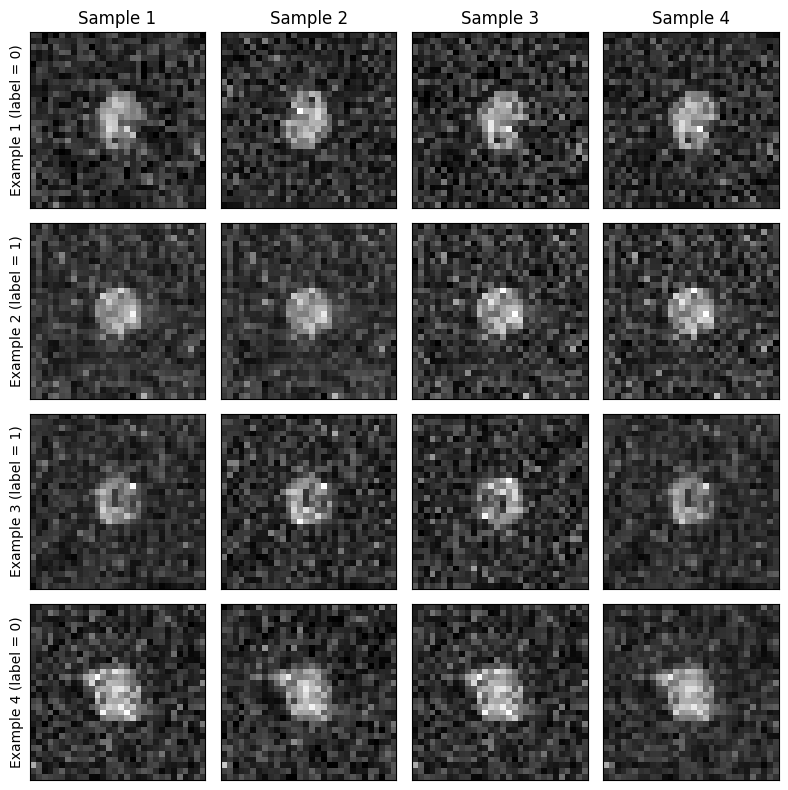

In [9]:
# @title
from monai.data import CacheDataset


# 1. Create cache datasets for each data split
# ============================================
train_ds = CacheDataset(
    data=files_train,
    transform=transforms_train,
    cache_rate=1.0,      # cache all data
    num_workers=4        # workers used during caching
)

# for validation and test, we do not use augmentation.
val_ds = CacheDataset(
    data=files_val,
    transform=transforms_inference,
    cache_rate=1.0,
    num_workers=4
)

test_ds = CacheDataset(
    data=files_test,
    transform=transforms_inference,
    cache_rate=1.0,
    num_workers=4
)

# 2. Plot some exmples to visualize augmentation output
# =====================================================
f, ax = plt.subplots(4, 4, figsize = (8, 8))
ax = ax.ravel()
for i in range(16):
    if i % 4 == 0:
        ax[i].set_ylabel(f"Example {int(i / 4) + 1} (label = {train_ds[int(i / 4)]["label"]})")
    if i < 4:
        ax[i].set_title(f"Sample {i+1}")
    ax[i].imshow(train_ds[int(i / 4)]["image"][0], cmap = "gray", clim = (0, 1))
    ax[i].set_xticks([]), ax[i].set_yticks([])

plt.tight_layout()
plt.show()

### Further execises 1
 - Try modifying the data augmentation pipeline parameters (2 cells prior) and review the results (previous cell).
 - Use the MONAI documentation to add random translations during augmentation
        
    _Hint_: This is achievable via the `RandAffined` function
    
 - Decide which augmentation combination you think most appropriate for moving forward.

## Classification model
 - The cell below defines the binary classification model, designed on LeNet.
 - One slight modification we have made is to allow the model to predict the penultimate layer seperately via the `featurize` method.
 - This does not make any difference to the final result, it just allows us to visualize this layer to see what is happening.

In [10]:
# @title
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. Define the model
# ===================
class LeNet(nn.Module):
    def __init__(self, num_classes, shape):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, padding=2)

        self.fc1 = nn.Linear(16 * (shape[0] // 4) * (shape[1] // 4), 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 2)
        self.classifier = nn.Linear(2, num_classes)

    def featurize(self, x):
        x = F.relu(self.conv1(x))                        # conv1 -> ReLU activation
        x = F.max_pool2d(x, kernel_size=2, stride=2)     # Max pooling with 2x2 kernel
        x = F.relu(self.conv2(x))                        # conv2 -> ReLU activation
        x = F.max_pool2d(x, kernel_size=2, stride=2)     # Max pooling with 2x2 kernel
        x = x.view(x.size(0), -1)                        # Flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)            # 2D embedding (for visualization)
        return x

    def forward(self, x):
        x = self.featurize(x)
        x = self.classifier(x)   # raw logits
        return x

    def classify(self, x):
        logits = self.forward(x)
        probs = torch.softmax(logits, dim=1)
        return probs

# 2. Count total number of model parameters
# =========================================
model = LeNet(num_classes=2, shape=SHAPE)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 107,112


## Model training
 - This cell shows how to train the model using the (augmented) training data.
 - `torch` is particularly well suited for this. It allows us to define the training schedule with considerable flexibility.
 - Almost all deep learning methods use _backpropagation_ to minimize a _loss_ function that defines how well the model is performing.
 - A training schedule is generally structured as two nested loops:
    ```
    for epoch in n_epochs:
        for training_data_batch in n_batches:
            prediction = model(training_data_batch)
            loss = loss(prediction, truth)
            backpropagation: compute gradietns of loss w.r.t. model parameters
            update model parameters using gradients to reduce loss
    ```
 - We split the training data into _batches_ so that they can be loaded into GPU memory efficiently.
 - Model parameter gradients are computed for each batch independently, making this an example of _stochastic gradient descent_.
 - The loss function must differentiatable with respect to the model parameters.
 - For binary classification tasks, we generally use _binary cross entropy_ as the loss.

    $$
        L_{\theta}(y, \widehat{y}) = -\frac{1}{N}\sum\limits_{i=1}^{N}[y_{i}\ln\widehat{y}_{i} + (1 - y _{i})\ln(1 - \widehat{y} _{i})]
    $$
    
    where $y_{i} \in $ {0,1} is the true label, and $\widehat{y}_{i} \in (0, 1)$ is the (soft) prediction from the model with parameters $\theta$.

 - When $\widehat{y}_{i} = y_{i}$, then $L=0$.

In [11]:
# @title
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm  # Used for monitoring progress as a progress bar

# 1. Define training hyper-parameters
# ===================================
LEARNING_RATE = 1e-3
N_EPOCHS = 50
BATCH_SIZE = 40

# 2. Determine whether a GPU is available
# =======================================
if torch.cuda.is_available():  # If GPU available
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

# 3. Create an instance of the model to be trained
# ================================================
model = LeNet(num_classes=2, shape=SHAPE)
model.to(DEVICE)

# 4. Create torch data loaders
# ============================
train_loader = DataLoader(train_ds,
                          batch_size=BATCH_SIZE,
                          shuffle=True,           # Each batch will be different
                          num_workers=4)
val_loader = DataLoader(val_ds,
                        batch_size=BATCH_SIZE,
                        shuffle=False,
                        num_workers=4)

# 5. Define the binary cross entropy loss as optimization criterion
# =================================================================
criterion = nn.CrossEntropyLoss()

# 6. Define the torch optimizer
# =============================
# Keeps track of parameter gradients to improve model parameters for each training epoch
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 7. Add storage to keep track of validation and training losses during each epoch
# ================================================================================
# Keep track of losses for latter plotting.
train_losses = []
val_losses = []

# 8. Loop through epochs
# ======================
pbar = tqdm(range(N_EPOCHS))
for epoch in pbar:

    # -------------------
    # TRAINING
    # -------------------

    # Tell the model it is in training mode.
    model.train()

    train_losses.append(0)

    for batch in train_loader:

        # Get data for the current batch
        images = batch["image"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        # Clear gradients from previous batch
        optimizer.zero_grad()

        # Predict based on current parameters
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Append to the running loss
        train_losses[-1] = train_losses[-1] + loss.item() * images.size(0)

        # Determine the gradients and back-propagate.
        loss.backward()
        optimizer.step()


    # -------------------
    # VALIDATION
    # -------------------

    # Put model into evaluation mode
    model.eval()

    val_losses.append(0)

    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            outputs = model(images)
            val_loss = criterion(outputs, labels)

            # Append to the running loss
            val_losses[-1] = val_losses[-1] + val_loss.item() * images.size(0)

            pbar.set_description(f"Train Loss: {loss.item():.4f} - Val Loss: {val_loss.item():.4f}")

# 9. Compute average loss over provided examples
# ===============================================
train_losses = np.array(train_losses) / len(train_ds)
val_losses = np.array(val_losses) / len(val_ds)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
  0%|          | 0/50 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Trai

 ## Training evaluation
 - The next cell plots the training curves that were accumulated, comparing change in loss with training epoch.
 - This information is ciritical to tell us about model convergence (i.e. have we reached an minimum possible loss).
 - __Note__: Dashed trainined curves are log-transformed.
 - ___Quiz___:
    - Do you think we have reached convergence?
    - Do you think the model is overtrained and if not, what evidence is there for this?
    - Is a 50% train/test split appropriate?

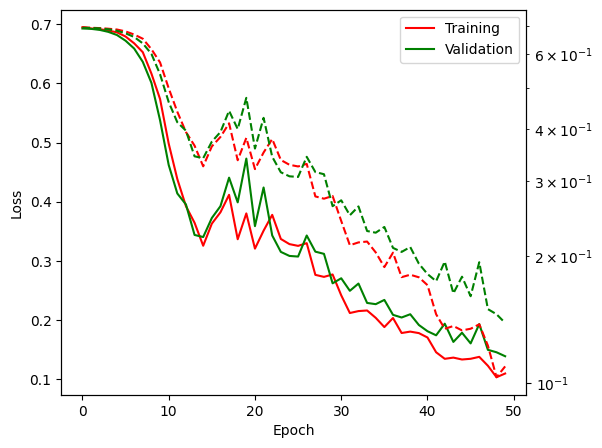

In [12]:
# @title
f, ax = plt.subplots(1, 1, figsize = (6, 5))
ax.plot(train_losses, "r-", label="Training")
ax.plot(val_losses, "g-", label="Validation")
ax.set_xlabel("Epoch"), ax.set_ylabel("Loss")
ax_log = ax.twinx()
ax_log.semilogy(train_losses, "r--")
ax_log.semilogy(val_losses, "g--")
ax.legend()
plt.show()

 - This network was sepcifcially designed to include the penultimate layer as a feature encoder we can visualize.
 - Let's see how the feature space seperates the labels.

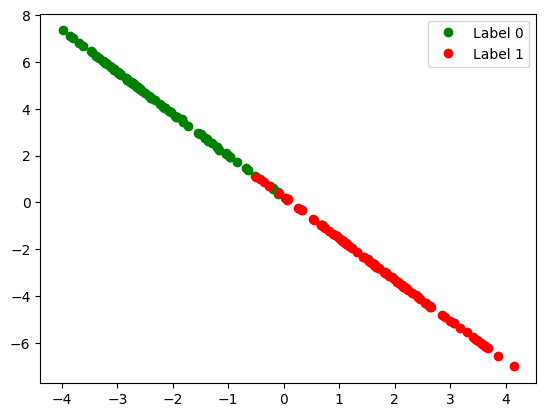

In [13]:
# @title
val_images = torch.stack(
    [val_ds[i]["image"] for i in range(len(val_ds))]
    ).to(DEVICE)
val_labels = np.array([val_ds[i]["label"] for i in range(len(val_ds))])

model.eval()
with torch.no_grad():
    val_features = model.featurize(val_images).cpu().numpy()
plt.plot(val_features[val_labels == 0, 0], val_features[val_labels == 0, 1], "go", label = "Label 0")
plt.plot(val_features[val_labels == 1, 0], val_features[val_labels == 1, 1], "ro", label = "Label 1")
plt.legend(loc="best")
plt.show()

 - This provides us with some context. The preceeding layers have discovered a _latent feature space_ that tries to linearly seperates the labels.
 - ___Quiz___: What do you think might happen to this feature seperation if we continued to train for further epochs?

## Model export
 - Once we have a trained model we would like to save it for future use.
 - Training AI models can be very costly, takes a long time, and has environmental impact.
 - `PyTorch` allows us to the model and its parameters.
 - It also allows us to save the training state so that we can continue training further epochs in the future (for example if the GPU becomes corrupted and we want to continue where we left off).
 - However the latter option comes at the cost of icreased storage costs.
 <br>

 - We will save weights to our Google drive as it interaces quite nicely with Colab.
 - We first need to mount the drive into colab (it will likely ask for permissions).

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


 - Next we define where in the drive the model should be stored.
 - Be cautious that if you don't redefine the filename, it will overwrite your previous work.
 - This network is quite light so should only store ~0.5 MB.

In [15]:
# 1. Define the export directory and ensure it exists
# ===================================================
export_directory = "/content/drive/MyDrive/imaging_workshop_2026/binary_classifier"
os.makedirs(export_directory, exist_ok=True)

# 2. Define the filename
# ======================
fname = f"checkpoint_{SNR}_{SHAPE}_{N_EPOCHS}_{LEARNING_RATE}_{BATCH_SIZE}.pth"
checkpoint_path = os.path.join(export_directory, fname)

# 3. Save the model (wiith training state)
# ========================================
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": epoch,
    "num_classes": 2,
    "shape": SHAPE,
    "loss": loss,
    "train_losses": train_losses,
    "val_losses": val_losses
}, checkpoint_path)

print("Saved to:", checkpoint_path)

Saved to: /content/drive/MyDrive/imaging_workshop_2026/binary_classifier/checkpoint_7.0_(30, 30)_50_0.001_40.pth


## Model performance


### Model loading
 - Let's evaluate our _saved_ model to ensure we are testing on the final produce.

In [16]:
# 1. Define the filename
# ======================
export_directory = "/content/drive/MyDrive/imaging_workshop_2026/binary_classifier"
fname = f"checkpoint_{SNR}_{SHAPE}_{N_EPOCHS}_{LEARNING_RATE}_{BATCH_SIZE}.pth"
checkpoint_path = os.path.join(export_directory, fname)
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError("That file does not exist" +
                            "Either you have lost connectivity to Googe Drive or that combination has not been trained.")

# 2. Load the model
# =================
checkpoint = torch.load(checkpoint_path,
                        map_location=DEVICE,
                        weights_only=False)
model = LeNet(num_classes=2, shape = checkpoint["shape"])
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (fc1): Linear(in_features=784, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=2, bias=True)
  (classifier): Linear(in_features=2, out_features=2, bias=True)
)

### Diagnostic performance
- Let's now unlock our test data and see how well we are doing.
 - Although the binary cross entropy is useful for model optimization (it is differentiatable with respect to model parameters), it is often not the metric of choice for evaluating how well a binary predictor works.
 - Common metrics include:

    - $FP$: Number of false positives
    - $FN$: Number of flase negatives
    - $TP$: Number of true positives
    - $TN$: Number of true negatives
    - Sensitivity, $Se = \frac{TP}{TP + FN}$
    - Specificity, $Sp = \frac{TN}{TN + FP}$
    - Accuracy, $Acc = \frac{TN + TP}{TN + TP + FN + FP}$

 <img src="https://raw.githubusercontent.com/mdblackledge/theoryofimaging2/main/workshop/figures/sensitivity.png?cache_bust=20260216" width=50%>

Confusion Matrix


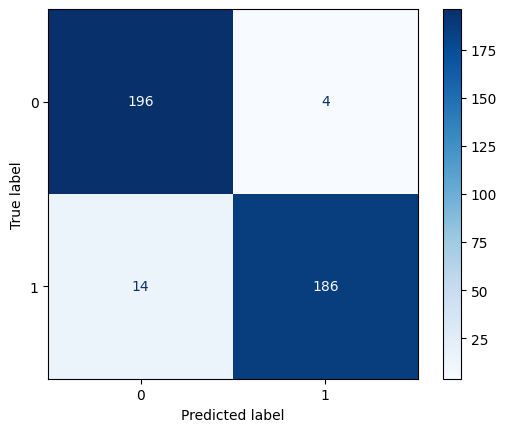



Summary Statistics
Sensitivity: 0.93
Specificity: 0.98
Accuracy: 0.955


In [17]:
# @title
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

# Get the test images and true labels
test_images = torch.stack(
    [test_ds[i]["image"] for i in range(len(test_ds))]
    ).to(DEVICE)
test_labels = np.array([test_ds[i]["label"] for i in range(len(test_ds))])

# Evaluate the test prediction probability and estimated labels
model.eval()
with torch.no_grad():
    test_prob = model.classify(test_images).cpu().numpy()
test_labels_pred = np.argmax(test_prob, axis=1)

# Plot a confusion matrix to summarize TP and TN
print("Confusion Matrix")
print("================")
cm = confusion_matrix(test_labels, test_labels_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

# Print some metrics
tp = np.sum(np.logical_and(test_labels == 1, test_labels_pred == 1))
tn = np.sum(np.logical_and(test_labels == 0, test_labels_pred == 0))
fp = np.sum(np.logical_and(test_labels == 0, test_labels_pred == 1))
fn = np.sum(np.logical_and(test_labels == 1, test_labels_pred == 0))
print("\n")
print("Summary Statistics")
print("==================")
print(f"Sensitivity: {float(tp) / (tp + fn)}")
print(f"Specificity: {float(tn) / (tn + fp)}")
print(f"Accuracy: {float(tn + tp) / (tn + fp + tp + fn)}")

 ### Receiver operating characteristic (ROC) curve
 - Another powerful diagnostic for binary classifier is the Receiver Operating Characteristic (ROC) curve.
 - In the diagnostic performance criteria defined above we needed to threshold our soft classifier to obtain the metrics:
    `test_labels_pred = np.argmax(test_prob, axis=1)`

 - The ROC lets us understand model performace regardless of threshold by plotting _1 - specificity_ against _sensitivity_ for a range of soft thresholds.
 - `sklearn` provides good visualization of this.

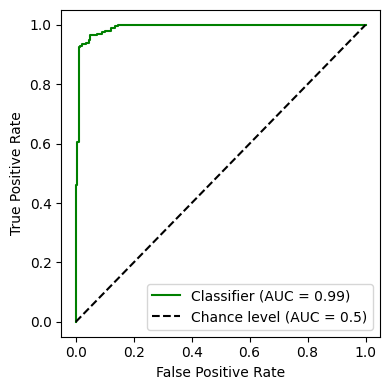

In [18]:
from sklearn.metrics import roc_curve, auc

f, ax = plt.subplots(1, 1, figsize = (4, 4))
fpr, tpr, _ = roc_curve(test_labels, test_prob[:, 1], pos_label=1)
auc_est = auc(fpr, tpr)
ax.plot(fpr, tpr, "g-", label = f"Classifier (AUC = {auc_est:.2f})")
ax.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.show()

### Further exercises 2
 - Train for further epochs to see if you can improve performance.
 - Modify the SNR of the sythetic images (e.g. SNR = 3 versus SNR = 10) and see how well classifier works now.
 - Increase the shape of the sythetic images to (50, 50) to see if more input data can improve classification outcome.
 - Modify the learning rate for training (e.g. 1e-6 and 1e-1) and visualize the success of classifier.
 - Add the following step to the `transforms_inference` MONAI Compose pipeline and retrain the model:
    ```
        RandAffined(keys=["image"], prob=1.0, translate_range=(0, 10), mode=("bilinear")),
    ```
    
    (remove the `RandAffined` step from `transforms_train` if you added it earlier...)

   What difference deos it make to model accuracy and why?

# __3. Multilabel classifier__
 - In total in this example we have 16 possible labels (block groups).
 - The LeNet architecture we defined further up can be extented to achieve this.

 ## Data splitting
 - Again we start by splitting our data.
 - In this example we will try to classify four different labels, but this can be changed by modifying `labels_dict`.

In [19]:
import random

from sklearn.model_selection import train_test_split


labels_dict = {0: "3022 Plate 2x2",
               1: "3005 Brick 1x1",
               2: "3003 Brick 2x2",
               3: "2357 Brick corner 1x2x2"}

# Loading the datasets as dictionaries is important for MONAI data reading.
files = []
for label in labels_dict.keys():
    label_files = [
        {"image": os.path.join(input_images_dir, labels_dict[label], fname), "label": label}
        for fname in os.listdir(os.path.join(input_images_dir, labels_dict[label]))
        if fname.endswith(".png")
    ]
    files = files + label_files

# Split into train/test (50/50)
test_fraction = 0.5

files_train, files_test = train_test_split(
    files,
    test_size=test_fraction,
    stratify=[f["label"] for f in files],
    random_state=2026,
)

# Further hold back some of the training data for validation
files_train, files_val = train_test_split(
    files_train,
    test_size=test_fraction,
    stratify=[f["label"] for f in files_train],
    random_state=2026,
)

 ## Data preprocessing
 - We could use the same MONAI pipelines identified earlier on, but must re-initialize the cached datasets.

Loading dataset: 100%|██████████| 790/790 [00:02<00:00, 357.08it/s]


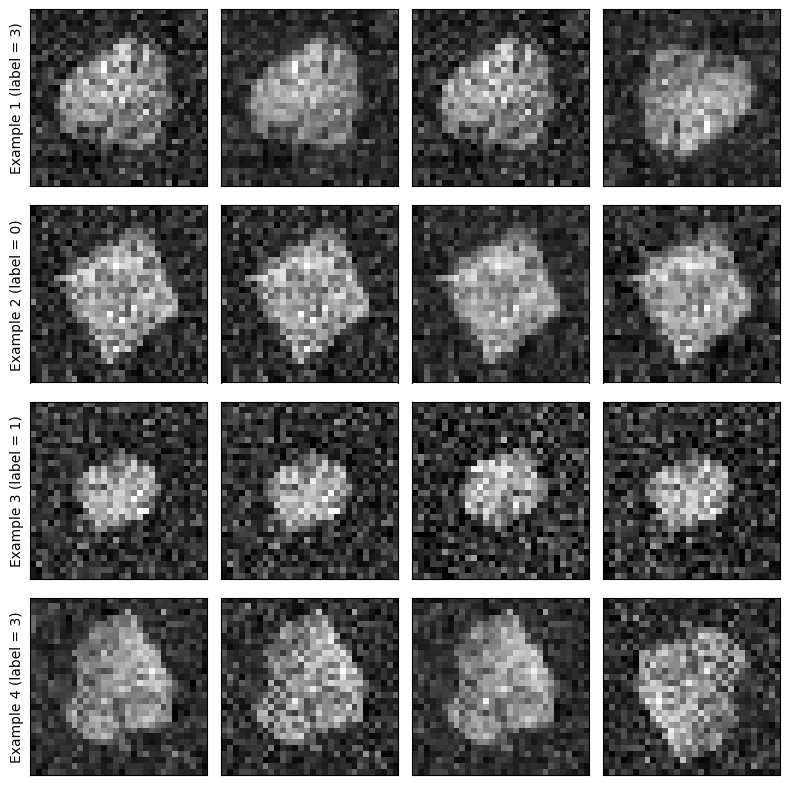

In [20]:
from monai.data import CacheDataset
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityd,
    ResizeD,
    RandAffined,
    RandFlipd,
    RandGaussianNoised,
    Rand2DElasticd,
    ToTensord,
)

# 1. Redefine the MONAI transforms for clarity
# ============================================
transforms_train = Compose([
    LoadImaged(keys=["image"]), # Load the images from file (preprocessing)
    EnsureChannelFirstd(keys=["image"]), # Ensure they are read as a single channel (preprocessing)
    ScaleIntensityd(keys=["image"], minv=0.0, maxv=1.0), # Scale image intensities to range 0 → 1 (preprocessing)
    ResizeD(keys=["image"], spatial_size=SHAPE), # Resize image to desired shape (preprocessing)
    RandFlipd(keys=["image"], prob=0.5),  # Randomly flip image with defined probability (augmentation)
    RandGaussianNoised(keys=["image"], prob=0.5, mean=0, std=0.1),  # Randomly add Guassian noise with defined probability, mean and standard-deviation (augmentation)
    Rand2DElasticd(keys=["image"], prob=0.5, spacing=(5, 5), magnitude_range=(0, 0.2)),  # Apply random elastic deformations to the iamges wth defined probability/parameters (augmentation)
    ToTensord(keys=["image"]), # Convert to Tensor format for PyTorch input (preprocessing)
])

# Note that augmentation steps should not be applied during inference.
transforms_inference = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityd(keys=["image"], minv=0.0, maxv=1.0),
    ResizeD(keys=["image"], spatial_size=SHAPE),
    ToTensord(keys=["image"]),
])

# 2. Create the cahced datasets
# =============================
train_ds = CacheDataset(
    data=files_train,
    transform=transforms_train,
    cache_rate=1.0,      # cache all data
    num_workers=4        # workers used during caching
)

# for validation and test, we do not use augmentation.
val_ds = CacheDataset(
    data=files_val,
    transform=transforms_inference,
    cache_rate=1.0,      # cache all data
    num_workers=4        # workers used during caching
)

test_ds = CacheDataset(
    data=files_test,
    transform=transforms_inference,
    cache_rate=1.0,      # cache all data
    num_workers=4        # workers used during caching
)

# Lets plot some examples
f, ax = plt.subplots(4, 4, figsize = (8, 8))
ax = ax.ravel()
for i in range(16):
    if i % 4 == 0:
        ax[i].set_ylabel(f"Example {int(i / 4) + 1} (label = {train_ds[int(i / 4)]["label"]})")
    ax[i].imshow(train_ds[int(i / 4)]["image"][0], cmap = "gray", clim = (0, 1))
    ax[i].set_xticks([]), ax[i].set_yticks([])

plt.tight_layout()
plt.show()

## Model training
 - Note that we change the number of classes our model can handle. The architecture is identical

In [22]:
# @title
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm  # Used for monitoring progress as a progress bar

# Some training hyper-parameters
LEARNING_RATE = 1e-3
N_EPOCHS = 50
BATCH_SIZE = 40

if torch.cuda.is_available():  # If GPU available
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

# Create an instance of the model to be trained
model = LeNet(num_classes=4, shape = SHAPE)
model.to(DEVICE)

# Data loaders will ensure efficient batching of data during training and validation
train_loader = DataLoader(train_ds,
                          batch_size=BATCH_SIZE,
                          shuffle=True,
                          num_workers=4)
val_loader = DataLoader(val_ds,
                        batch_size=BATCH_SIZE,
                        shuffle=False,
                        num_workers=4)

# Binary cross entropy loss
criterion = nn.CrossEntropyLoss()

# This keeps track of all parameter gradients that are used to improve
# the model parameters for each training epoch
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Keep track of losses for latter plotting.
train_losses = []
val_losses = []

pbar = tqdm(range(N_EPOCHS))
for epoch in pbar:

    train_losses.append(0)
    val_losses.append(0)

    # -------------------
    # TRAINING
    # -------------------

    # Tell the model it is in training mode.
    model.train()

    for batch in train_loader:

        # Get data for the current batch
        images = batch["image"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        # Clear gradients from previous batch
        optimizer.zero_grad()

        # Predict based on current parameters
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Append to the running loss
        train_losses[-1] = train_losses[-1] + loss.item() * images.size(0)

        # Determine the gradients and back-propagate.
        loss.backward()
        optimizer.step()


    # -------------------
    # VALIDATION
    # -------------------

    # Put model into evaluation mode
    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            outputs = model(images)
            val_loss = criterion(outputs, labels)

            # Append to the running loss
            val_losses[-1] = val_losses[-1] + val_loss.item() * images.size(0)

            pbar.set_description(f"Train Loss: {loss.item():.4f} - Val Loss: {val_loss.item():.4f}")

train_losses = np.array(train_losses) / len(train_ds)
val_losses = np.array(val_losses) / len(val_ds)

  0%|          | 0/50 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Train Loss: 0.2079 - Val Loss: 0.3880: 100%|██████████| 50/50 [02:03<00:00,  2.47s/it]


## Training evaluation
- Again, we will plot the training and validation curves.

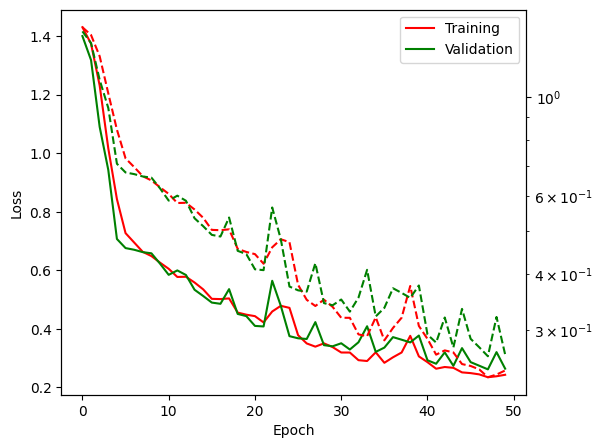

In [23]:
f, ax = plt.subplots(1, 1, figsize = (6, 5))
ax.plot(train_losses, "r-", label="Training")
ax.plot(val_losses, "g-", label="Validation")
ax.set_xlabel("Epoch"), ax.set_ylabel("Loss")
ax_log = ax.twinx()
ax_log.semilogy(train_losses, "r--")
ax_log.semilogy(val_losses, "g--")
ax.legend()
plt.show()

- We are seeing a reduction in the loss over time, but clearly convergence is
not yet achieved.
- We will need to train for further epochs for more accuracy.
- Looking at the latent feature space might help improve interpretation of what is going on.

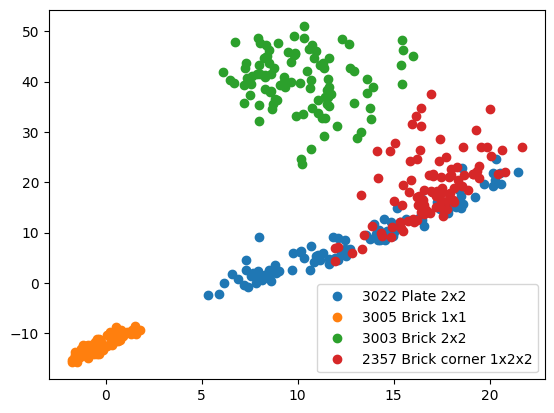

In [24]:
# @title
val_images = torch.stack(
    [val_ds[i]["image"] for i in range(len(val_ds))]
    ).to(DEVICE)
val_labels = np.array([val_ds[i]["label"] for i in range(len(val_ds))])

model.eval()
with torch.no_grad():
    val_features = model.featurize(val_images).cpu().numpy()

for label, label_name in labels_dict.items():
    plt.plot(val_features[val_labels == label, 0], val_features[val_labels == label, 1], "o", label = f"{label_name}")
plt.legend(loc="best")
plt.show()

___Quiz___:
    
 - Why might training convergence be harder here?
 - What might happen if we add more classes?


## Model export
 - We follow exactly the same pattern as earlier, but ensure that the export directory is different.

In [25]:
# 1. Ensure Google Drive is still mounted
# =======================================
from google.colab import drive
drive.mount('/content/drive')

# 2. Define the export directory and ensure it exists
# ===================================================
export_directory = "/content/drive/MyDrive/imaging_workshop_2026/multilabel_classifier"
os.makedirs(export_directory, exist_ok=True)

# 3. Define the filename
# ======================
fname = f"checkpoint_{SNR}_{SHAPE}_{N_EPOCHS}_{LEARNING_RATE}_{BATCH_SIZE}.pth"
checkpoint_path = os.path.join(export_directory, fname)

# 4. Save the model (wiith training state)
# ========================================
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": epoch,
    "num_classes": 2,
    "shape": SHAPE,
    "loss": loss,
    "train_losses": train_losses,
    "val_losses": val_losses
}, checkpoint_path)

print("Saved to:", checkpoint_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to: /content/drive/MyDrive/imaging_workshop_2026/multilabel_classifier/checkpoint_7.0_(30, 30)_50_0.001_40.pth


### Model loading

In [ ]:
# 1. Define the filename
# ======================
export_directory = "/content/drive/MyDrive/imaging_workshop_2026/multilabel_classifier"
fname = f"checkpoint_{SNR}_{SHAPE}_{N_EPOCHS}_{LEARNING_RATE}_{BATCH_SIZE}.pth"
checkpoint_path = os.path.join(export_directory, fname)
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError("That file does not exist" +
                            "Either you have lost connectivity to Googe Drive or that combination has not been trained.")

# 2. Load the model
# =================
checkpoint = torch.load(checkpoint_path,
                        map_location=DEVICE,
                        weights_only=False)
model = LeNet(num_classes=2, shape = checkpoint["shape"])
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)

## Model performance

Confusion Matrix


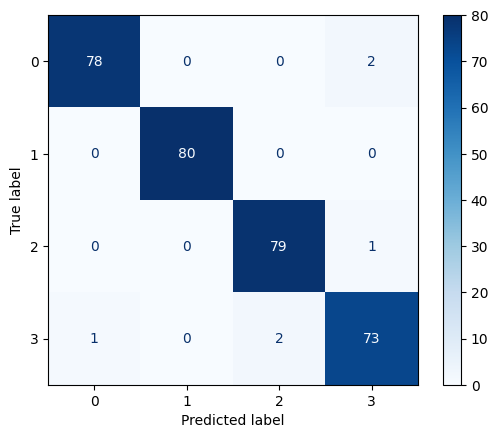

In [62]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

# Get the test images and true labels
test_images = torch.stack(
    [test_ds[i]["image"] for i in range(len(test_ds))]
    ).to(device)
test_labels = np.array([test_ds[i]["label"] for i in range(len(test_ds))])

# Evaluate the test prediction probability and estimated labels
model.eval()
with torch.no_grad():
    test_prob = model.classify(test_images).cpu().numpy()
test_labels_pred = np.argmax(test_prob, axis=1)

# Plot a confusion matrix to summarize TP and TN
print("Confusion Matrix")
print("================")
cm = confusion_matrix(test_labels, test_labels_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()


### Exercise 3
 - Try training for more epochs (e.g. 100) and see if it improves results.
 - Although the 2D featurization is helpful for visualization of latent space, it acts as a _bottleneck_ that can impede performance. Try to redefine the `LeNet` model class to increase the dimensions of feature space.
 - If you want to be adventurous, try increasing the number of classes.
 - Once running, this is good time to a little break!

# __4. Image segmentation__
 - Next we turn our attention to automatic _image segmentation_
 - This is a common task in medical imaging applications, for example:
    - Delineation of the tumour for biomarker extraction
    - Contouring of organs at risk for radiotherapy planning
    - Evaluation of body composition (e.g. fat, muscle, bone)
 - Rather than our classification task where we try to obtain a single, global label given an image, we generate a map of labels, with each label representing a specific region of interest.
 - Background (or anything not relevant) is typically given label 0.
 - Many real-word tasks are binary (region of interest versus background).

 ## Dataset generation
 - In this example our task is to delineate the lego block from background given the noisy images as input.
 - We will generate ground truth contours from the uncorrupted images using traditional image processing.

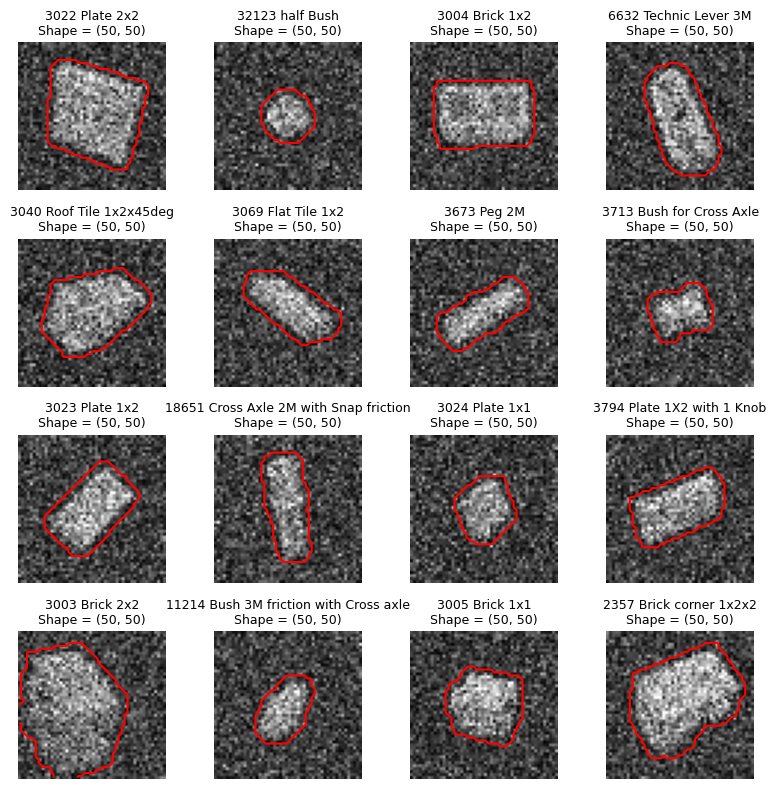

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from tqdm import tqdm

def segment_clean_image(arr, shape = (50, 50)):
    # Use the first channel (red)
    arr_bw = arr[..., 0].astype("float32")

    arr_bw = resize(
        arr_bw,
        shape,
        order=1,               # 1 = Bilnear
        mode='reflect',
        anti_aliasing=True,
        preserve_range=True    # keeps original value range
    )

    # Remove everything that is background
    mask = 1 * (arr_bw > 0)

    return mask

# Global parameters for the experiments
SHAPE = (50, 50)
SNR = 5.0

# Random seed
np.random.seed(2026)

f, ax = plt.subplots(4, 4, figsize = (8, 8))
ax = ax.ravel()
for i in range(16):

    # Randomly select a block type and image
    block_group_dir = clean_data_path + "/" + os.listdir(clean_data_path)[i]
    block_file = block_group_dir + "/" + np.random.choice(os.listdir(block_group_dir))

    # Degrade the image.
    arr = skimage.io.imread(block_file)
    arr_noisy = degrade_lego_image(arr, snr=SNR, shape=SHAPE)

    # Obtain the mask
    mask = segment_clean_image(arr, shape=SHAPE)

    # Display
    ax[i].imshow(arr_noisy, cmap = "gray")
    ax[i].contour(mask, [0.5], colors = ["r"])
    ax[i].set_title(block_file.split("/")[-2] + "\n"\
                    + f"Shape = {arr_noisy.shape}", fontsize = 9.)
    ax[i].axis("off")

plt.tight_layout()
plt.show()

 - We'll organize the degraded images and masks into two subfolders

In [82]:
images_dir = "/content/segmentation_images/images"
masks_dir = "/content/segmentation_images/masks"
force = True

if not os.path.exists(images_dir) or force:
    for block_group_dir in tqdm(os.listdir(clean_data_path), desc = "Resampling images"):
        block_group_path = clean_data_path + "/" + block_group_dir
        for block_file in os.listdir(block_group_path):
            # Read the clean image
            block_path = block_group_path + "/" + block_file
            arr = skimage.io.imread(block_path)

            # Degrade and create the downsampled mask
            arr_noisy = degrade_lego_image(arr, snr=SNR, shape=SHAPE)
            mask = (segment_clean_image(arr, shape=SHAPE) * 255).astype("uint8")

            # Save the noisy image
            os.makedirs(images_dir + "/" + block_group_dir, exist_ok=True)
            skimage.io.imsave(images_dir + "/" + block_group_dir + "/" + block_file, arr_noisy)

            # Save the mask
            os.makedirs(masks_dir + "/" + block_group_dir, exist_ok=True)
            skimage.io.imsave(masks_dir + "/" + block_group_dir + "/" + block_file, mask.astype("uint8"))

Resampling images: 100%|██████████| 16/16 [00:41<00:00,  2.61s/it]


## Data splitting
 - For our "external validation", we will hold two block types back from training.
 - We will split remaining blocks into 80/20 training/test also.

In [ ]:
# @title
import random

from sklearn.model_selection import train_test_split
import monai

# These will be left for "external validation"
ext_validation_block_groups = ["32123 half Bush",
                               "6632 Technic Lever 3M"]

block_groups = os.listdir(clean_data_path)

# Loading the datasets as dictionaries is important for MONAI data reading.
files = []
for block_group in block_groups:
    if block_group in ext_validation_block_groups:
        continue
    files_ = [
        {"image": os.path.join(images_dir, block_group, fname),
         "mask": os.path.join(masks_dir, block_group, fname),
         "group": block_group}
        for fname in os.listdir(os.path.join(images_dir, block_group))
        if fname.endswith(".png")
    ]
    files = files + files_

# Split into train/test (80/20)
test_fraction = 0.2

files_train, files_test = train_test_split(
    files,
    test_size=test_fraction,
    stratify=[f["group"] for f in files],
    random_state=2026,
)

# Further hold back some of the training data for validation
files_train, files_val = train_test_split(
    files_train,
    test_size=test_fraction,
    stratify=[f["group"] for f in files_train],
    random_state=2026,
)

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


## Data preprocessing
 - Similar steps will be used for image preprocessing and augmentation as for the classification task.
 - However, we must perform the same spatial operations to the masks as to the images to make sure they align well.
 - We intriduce one additional step `Lambdad`, which allows us to define an aribtrary operation within the pipeline.
 - Here we use it to convert the mask labels back to 0 and 1 (we needed to images files with the range (0, 255))

In [ ]:
# @title
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityd,
    Lambdad,
    ResizeD,
    RandAffined,
    RandFlipd,
    RandGaussianNoised,
    Rand2DElasticd,
    ToTensord,
)

transforms_train = Compose([
    LoadImaged(keys=["image", "mask"]),
    EnsureChannelFirstd(keys=["image", "mask"]),
    ScaleIntensityd(keys=["image"]),
    Lambdad(keys=["mask"], func=lambda x: x / 255.0),
    ResizeD(keys=["image", "mask"], spatial_size=(50, 50), mode=("bilinear", "nearest")),
    RandFlipd(keys=["image", "mask"], prob=0.5),
    RandAffined(keys=["image", "mask"], prob=1.0, translate_range=(0, 15), mode=("bilinear", "nearest")),
    RandGaussianNoised(keys=["image"], prob=0.5, mean=0, std=0.1),
    Rand2DElasticd(keys=["image", "mask"], prob=0.5, spacing=(5, 5), magnitude_range=(0, 0.2), mode=("bilinear", "nearest")),
    ToTensord(keys=["image", "mask"]),
])

# Note that augmentaiotn is NOT applied during inference.
transforms_inference = Compose([
    LoadImaged(keys=["image", "mask"]),
    EnsureChannelFirstd(keys=["image", "mask"]),
    ScaleIntensityd(keys=["image"]),
    Lambdad(keys=["mask"], func=lambda x: x / 255.0),
    ResizeD(keys=["image", "mask"], spatial_size=(50, 50), mode=("bilinear", "nearest")),
    ToTensord(keys=["image", "mask"]),
])

 - Again we will use the `DatasetCache` for efficient loading of data during training.

Loading dataset: 100%|██████████| 1116/1116 [00:04<00:00, 237.76it/s]


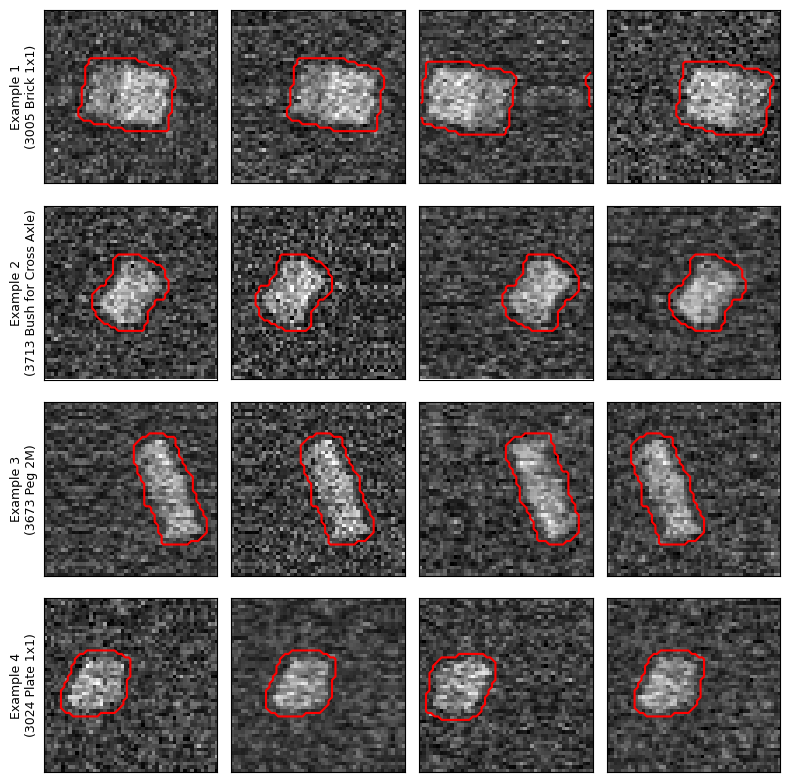

In [ ]:
from monai.data import CacheDataset

train_ds = CacheDataset(
    data=files_train,
    transform=transforms_train,
    cache_rate=1.0,      # cache all data
    num_workers=4        # workers used during caching
)

# for validation and test, we do not use augmentation.
val_ds = CacheDataset(
    data=files_val,
    transform=transforms_inference,
    cache_rate=1.0,      # cache all data
    num_workers=4        # workers used during caching
)

test_ds = CacheDataset(
    data=files_test,
    transform=transforms_inference,
    cache_rate=1.0,      # cache all data
    num_workers=4        # workers used during caching
)

# Lets plot some examples
f, ax = plt.subplots(4, 4, figsize = (8, 8))
ax = ax.ravel()
for i in range(16):
    sample = train_ds[int(i / 4)]
    image = sample["image"][0]
    mask = sample["mask"][0]
    if i % 4 == 0:
        ax[i].set_ylabel(f"Example {int(i / 4) + 1}\n({sample["group"]})", fontsize = 9.)
    ax[i].imshow(image, cmap = "gray", clim = (0, 1))
    ax[i].contour(mask, [0.5], colors = ["r"])
    ax[i].set_xticks([]), ax[i].set_yticks([])

plt.tight_layout()
plt.show()

## Segmentation model
 - We will use a deep-learning architecture that has represented the cornerstone of medical image segmentation for the past decade, the __U-Net__.
 - It is similar in design to an autoencoder, with both a downsampling (encoder) arm and an upsampling (decoder) arm.
 - It's key contribution was the addition of _skip connections_, which allows propagation of high-resolution details through concatenation of every downsample step with each upsample step.
 - The U-Net is now also used as a backbone architeture for non-segmentation tasks, including image reconstruction and generative image AI via denoising diffusion probabilistic models (DDPMs).

 <img src="https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png" width=50%>

   _Source: https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/_


 - This implementation of the U-Net demonstrates how `torch` enables nice _modular_ model design, with the main model consisting of different subunits.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    """ Performs one step of the U-Net model """
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class Down(nn.Module):
    """ Downscale with maxpool then double conv """
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch),
        )

    def forward(self, x):
        return self.net(x)


class Up(nn.Module):
    """Upscale then concat skip connection then double conv"""
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)

    @staticmethod
    def _pad_or_crop_to_match(x: torch.Tensor, ref: torch.Tensor) -> torch.Tensor:
        """Pad/crop x spatially to match ref (N,C,H,W)."""
        diff_y = ref.size(-2) - x.size(-2)
        diff_x = ref.size(-1) - x.size(-1)

        # Pad if x is smaller
        if diff_y > 0 or diff_x > 0:
            x = F.pad(
                x,
                [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2],
            )

        # Crop if x is larger
        if diff_y < 0 or diff_x < 0:
            y0 = (-diff_y) // 2
            x0 = (-diff_x) // 2
            x = x[..., y0 : y0 + ref.size(-2), x0 : x0 + ref.size(-1)]

        return x

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        x = self._pad_or_crop_to_match(x, skip)
        x = torch.cat([skip, x], dim=1)         # Concatenate upscaled with same resolution on down arm.
        x = self.conv(x)
        return x

class UNet2D(nn.Module):
    """
    Simple fully-convolutional 2D U-Net.

    - Works with arbitrary HxW (padding/cropping keeps skips aligned).
    - Outputs raw logits (no softmax/sigmoid).
    """
    def __init__(self, in_channels: int = 1, num_classes: int = 2, base_channels: int = 32):
        super().__init__()
        self.inc = DoubleConv(in_channels, base_channels)
        self.down1 = Down(base_channels * 1, base_channels * 2)
        self.down2 = Down(base_channels * 2, base_channels * 4)
        self.down3 = Down(base_channels * 4, base_channels * 8)
        self.down4 = Down(base_channels * 8, base_channels * 16)

        self.up1 = Up(base_channels * 16, base_channels * 8)
        self.up2 = Up(base_channels * 8, base_channels * 4)
        self.up3 = Up(base_channels * 4, base_channels * 2)
        self.up4 = Up(base_channels * 2, base_channels * 1)

        self.outc = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x)
        return logits

model = UNet2D(num_classes=2)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 7,762,498


## Model training

In [ ]:
# @title
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm  # Used for monitoring progress as a progress bar

# Some training hyper-parameters
learning_rate = 1e-3
num_epochs = 20
batch_size = 400
if torch.cuda.is_available():  # If GPU available
    device = "cuda"
else:
    device = "cpu"

# Create an instance of the model to be trained
model = UNet2D(num_classes=2)
model.to(device)

# Data loaders will ensure efficient batching of data during training and validation
train_loader = DataLoader(train_ds,
                          batch_size=batch_size,
                          shuffle=True,
                          num_workers=4)
val_loader = DataLoader(val_ds,
                        batch_size=batch_size,
                        shuffle=True,
                        num_workers=4)

# Binary cross entropy loss
criterion = nn.CrossEntropyLoss()

# This keeps track of all parameter gradients that are used to improve
# the model parameters for each training epoch
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Keep track of losses for latter plotting.
train_losses = []
val_losses = []

pbar = tqdm(range(num_epochs))
for epoch in pbar:

    train_losses.append(0)
    val_losses.append(0)

    # -------------------
    # TRAINING
    # -------------------

    # Tell the model it is in training mode.
    model.train()

    for batch in train_loader:

        # Get data for the current batch
        images = batch["image"].to(device)
        masks = batch["mask"].squeeze(1).long().to(device)

        # Clear gradients from previous batch
        optimizer.zero_grad()

        # Predict based on current parameters
        outputs = model(images)
        loss = criterion(outputs, masks)

        # Append to the running loss
        train_losses[-1] = train_losses[-1] + loss.item() * images.size(0)

        # Determine the gradients and back-propagate.
        loss.backward()
        optimizer.step()


    # -------------------
    # VALIDATION
    # -------------------

    # Put model into evaluation mode
    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].to(device)
            masks = batch["mask"].squeeze(1).long().to(device)

            outputs = model(images)
            val_loss = criterion(outputs, masks)

            # Append to the running loss
            val_losses[-1] = val_losses[-1] + loss.item() * images.size(0)

            pbar.set_description(f"Train Loss: {loss.item():.4f} - Val Loss: {val_loss.item():.4f}")

train_losses = np.array(train_losses) / len(train_ds)
val_losses = np.array(val_losses) / len(val_ds)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Train Loss: 0.0529 - Val Loss: 0.0476: 100%|██████████| 20/20 [07:41<00:00, 23.09s/it]


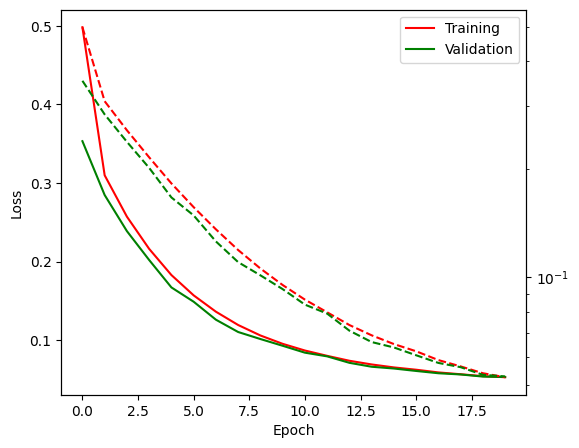

In [ ]:
f, ax = plt.subplots(1, 1, figsize = (6, 5))
ax.plot(train_losses, "r-", label="Training")
ax.plot(val_losses, "g-", label="Validation")
ax.set_xlabel("Epoch"), ax.set_ylabel("Loss")
ax_log = ax.twinx()
ax_log.semilogy(train_losses, "r--")
ax_log.semilogy(val_losses, "g--")
ax.legend()
plt.show()

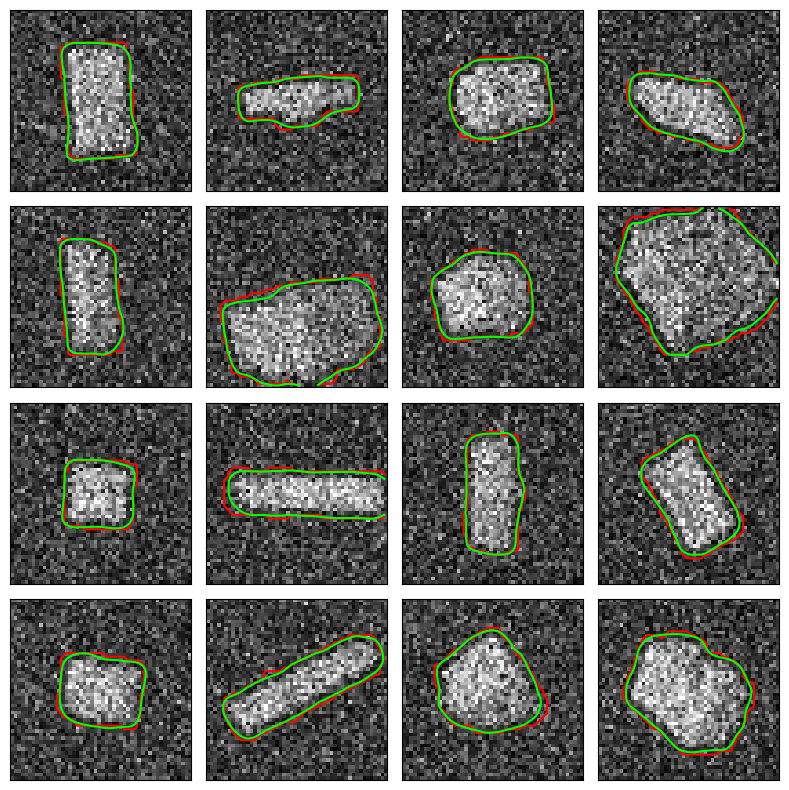

In [ ]:
val_images = torch.stack(
    [val_ds[i]["image"] for i in range(len(val_ds))]
    ).to(device)
val_masks_true = np.array([val_ds[i]["mask"] for i in range(len(val_ds))])[:, 0, ...]

model.eval()
with torch.no_grad():
    val_masks_pred = model(val_images).cpu().numpy()

f, ax = plt.subplots(4, 4, figsize = (8, 8))
ax = ax.ravel()
for i, idx in enumerate(np.random.choice(np.arange(val_images.shape[0]), size = 16)):
    ax[i].imshow(val_images[idx].cpu().numpy()[0], cmap = "gray")
    ax[i].contour(val_masks_true[idx], [0.5], colors = ["r"])
    ax[i].contour(val_masks_pred[idx, 1, ...], [0.5], colors = [(0, 1, 0)])
    ax[i].set_xticks([]), ax[i].set_yticks([])
plt.tight_layout()
plt.show()